In [1]:
import numpy as np
import pandas as pd
import os,sys
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = (10, 6)

cwd = os.getcwd() #grabs current working directory

testfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'TEMP' / '2026-08-forTCurtis')
inputfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'TEMP')
baselinesfolder = str(Path().resolve().parent.parent /'PV_ICE' / 'baselines')
supportMatfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'baselines' / 'SupportingMaterial')

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

In [2]:
#creating scenarios for identical power of multiple technologies
scennames = ['base'] #might need a PV ICE baseline too
MATERIALS = ['glass','silver','silicon', 'copper', 'aluminium_frames', 'encapsulant', 'backsheet']
moduleFile_m = os.path.join(baselinesfolder, 'baseline_modules_mass_World.csv')
#moduleFile_e = os.path.join(baselinesfolder, 'baseline_modules_energy.csv')
#moduledeploy = pd.read_csv(os.path.join(supportMatfolder, 'output_Global_SiPV_installs.csv'))

In [3]:
#load in a baseline and materials for modification
import PV_ICE

PV_ICE.__version__

'0.4.3'

In [4]:
sim1 = PV_ICE.Simulation(name='sim1', path=testfolder)
for scen in scennames:
    sim1.createScenario(name=scen, massmodulefile=moduleFile_m)
    for mat in range (0, len(MATERIALS)):
        matbaseline_m = os.path.join(baselinesfolder,'baseline_material_mass_'+MATERIALS[mat]+'.csv')
        #matbaseline_e = os.path.join(baselinesfolder,'baseline_material_energy_'+MATERIALS[mat]+'.csv')
        sim1.scenario[scen].addMaterial(MATERIALS[mat], massmatfile=matbaseline_m)#, energymatfile=matbaseline_e)

path = C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_ICE\TEMP\2026-08-forTCurtis
Baseline folder directed to default:  C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\baselines
No energy module file passed. If desired, pass one of the following options:  ['baseline_modules_energy.csv']


In [5]:
#Lifetime and Degradation
#values taken from lifetime vs recycling paper
#degradation rate:
#sim1.modifyScenario('test', 'mod_degradation',0.2, start_year=2000) 
#sim1.modifyScenario('test', 'mod_lifetime', 50, start_year=2000) 
#sim1.modifyScenario('test', 'new_Installed_Capacity_[MW]', 0.0, start_year=1995) 
#sim1.modifyScenario('test', 'mod_eff', 17.0, start_year=1995) 

#sim1.scenMod_perfectRecycling()
sim1.scenMod_noCircularity()

In [6]:
#trim to start in 2000, this trims module and materials
#had to specify and end year, cannot use to extend
sim1.trim_Years(startYear=2000, endYear=2100)

Trimming and extending  base
No energy data loaded. Skipping for all next scenarios and materials
base backsheet : Data trimmed for Mass, years now encompass  2000  to  2100


C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1873: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  extended = pd.concat([reduced,add]) #concat the trimmed early years with the new extended years
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1876: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays o

In [7]:
sim1.scenario['base'].dataIn_m

,year,new_Installed_Capacity_[MW],mod_eff,mod_reliability_t50,mod_reliability_t90,mod_degradation,mod_lifetime,mod_MFG_eff,mod_Repair,mod_MerchantTail,...,mod_EOL_pg1_landfill,mod_EOL_pg2_stored,mod_EOL_pg3_reMFG,mod_EOL_pg4_recycled,mod_EOL_reMFG_yield,mod_EOL_sp_reMFG_recycle,mod_EOL_pb1_landfill,mod_EOL_pb2_stored,mod_EOL_pb3_reMFG,mod_EOL_pb4_recycled
0,2000,2.501100e+02,13.420000,22.5,24.0,0.75,20.0,95,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
1,2001,2.750630e+02,13.600000,22.5,24.0,0.75,20.0,95,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
2,2002,3.788416e+02,13.722222,22.5,24.0,0.75,20.0,95,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
3,2003,4.785891e+02,13.844444,22.5,24.0,0.75,20.0,96,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
4,2004,1.005038e+03,13.966667,22.5,24.0,0.75,20.0,96,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,2096,1.966000e+06,25.061727,41.0,44.0,0.50,35.0,98,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
97,2097,1.966000e+06,25.061727,41.0,44.0,0.50,35.0,98,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
98,2098,1.966000e+06,25.061727,41.0,44.0,0.50,35.0,98,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0
99,2099,1.966000e+06,25.061727,41.0,44.0,0.50,35.0,98,0.0,0.0,...,100.0,0.0,0.0,0.0,0,0.0,100.0,0.0,0.0,0.0


In [9]:
sim1.calculateMassFlow(scenarios='base')

>>>> Calculating Material Flows <<<<

Working on Scenario:  base
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silver
==> Working on Material :  silicon
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
==> Working on Material :  backsheet


In [16]:
sim1.scenario['base'].dataOut_m.keys()

Index(['Area', 'Cumulative_Active_Area', 'EOL_BadStatus', 'EOL_Landfill0',
       'EOL_PATHS', 'EOL_PG', 'Effective_Capacity_[W]', 'Landfill_0_ProjLife',
       'MerchantTail_Area', 'MerchantTail_[W]', 'ModuleTotal_MFG', 'P2_stored',
       'P3_reMFG', 'P4_recycled', 'PB1_landfill', 'PB2_stored', 'PB3_reMFG',
       'PB3_reMFG_unyield', 'PB3_reMFG_yield', 'PB4_recycled', 'PG1_landfill',
       'PG2_stored', 'PG3_reMFG', 'PG3_reMFG_unyield', 'PG3_reMFG_yield',
       'PG4_recycled', 'Power_Degraded_[W]', 'Repaired_Area', 'Repaired_[W]',
       'Resold_Area', 'Resold_[W]', 'WeibullParams',
       'Yearly_Sum_Area_EOLby_Degradation', 'Yearly_Sum_Area_EOLby_Failure',
       'Yearly_Sum_Area_EOLby_ProjectLifetime', 'Yearly_Sum_Area_PathsBad',
       'Yearly_Sum_Area_PathsGood', 'Yearly_Sum_Area_atEOL',
       'Yearly_Sum_Power_EOLby_Degradation', 'Yearly_Sum_Power_EOLby_Failure',
       'Yearly_Sum_Power_EOLby_ProjectLifetime', 'Yearly_Sum_Power_PathsBad',
       'Yearly_Sum_Power_PathsGood

Text(0.5, 1.0, 'Effective capacity in TW')

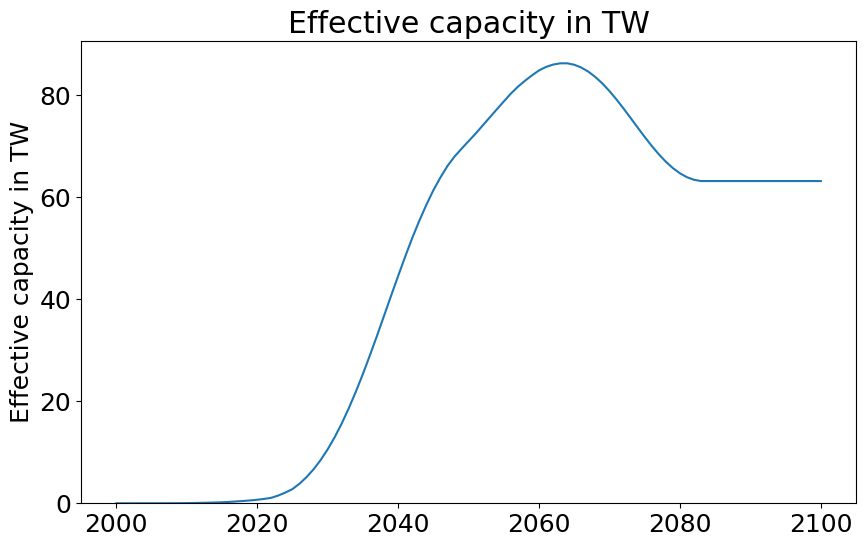

In [84]:
plt.plot(sim1.scenario['base'].dataIn_m['year'], sim1.scenario['base'].dataOut_m['Effective_Capacity_[W]']/1e12)
plt.ylim(0,)
plt.ylabel('Effective capacity in TW')
plt.title('Effective capacity in TW')
#plt.plot(sim1.scenario['base'].dataIn_m['new_Installed_Capacity_[MW]'])

Good, this deployment aligns with Haegel et al 2023

In [22]:
sim1_annual, sim1_cumu = sim1.aggregateResults()

In [35]:
#MASS
sim1_cumu.filter(like='WasteEOL')

,WasteEOL_glass_sim1_base_[Tonnes],WasteEOL_silver_sim1_base_[Tonnes],WasteEOL_silicon_sim1_base_[Tonnes],WasteEOL_copper_sim1_base_[Tonnes],WasteEOL_aluminium_frames_sim1_base_[Tonnes],WasteEOL_encapsulant_sim1_base_[Tonnes],WasteEOL_backsheet_sim1_base_[Tonnes],WasteEOL_Module_sim1_base_[Tonnes]
year,,,,,,,,
2000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2001,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2002,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2003,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2004,1.142162e-10,6.474429e-13,1.092539e-11,7.675331e-14,3.474975e-11,1.207837e-11,3.032441e-12,1.757264e-10
...,...,...,...,...,...,...,...,...
2096,4.314492e+09,1.330429e+06,1.359485e+08,2.778149e+06,6.345729e+08,2.718405e+08,1.147893e+08,5.475752e+09
2097,4.399214e+09,1.356186e+06,1.385977e+08,2.831849e+06,6.469671e+08,2.771222e+08,1.169680e+08,5.583057e+09
2098,4.483936e+09,1.381942e+06,1.412469e+08,2.885549e+06,6.593613e+08,2.824039e+08,1.191467e+08,5.690362e+09


Text(0, 0.5, 'Module EoL Mass [Million metric tonnes]')

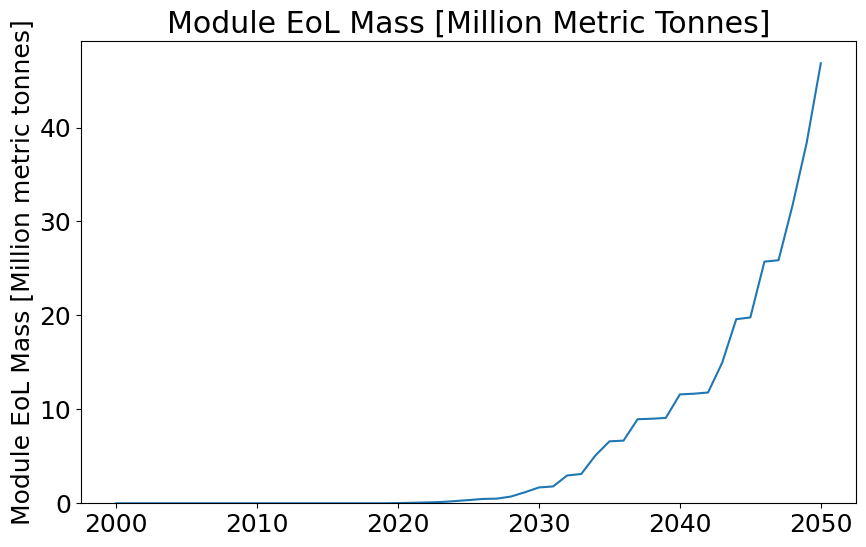

In [43]:
eol_module_tonnes = sim1_cumu.loc[:2050,'WasteEOL_Module_sim1_base_[Tonnes]']
plt.plot(eol_module_tonnes/1e6)
plt.ylim(0,)
plt.title('Module EoL Mass [Million Metric Tonnes]')
plt.ylabel('Module EoL Mass [Million metric tonnes]')

In [89]:
eol_cumu_all = sim1_cumu.filter(like='WasteEOL')
eol_cumu_all_mats_2050 = eol_cumu_all.loc[:2050].iloc[:,:7]
#eol_cumu_all_mats_2050

In [90]:
eol_cumu_all_mats_2050.columns

Index(['WasteEOL_glass_sim1_base_[Tonnes]',
       'WasteEOL_silver_sim1_base_[Tonnes]',
       'WasteEOL_silicon_sim1_base_[Tonnes]',
       'WasteEOL_copper_sim1_base_[Tonnes]',
       'WasteEOL_aluminium_frames_sim1_base_[Tonnes]',
       'WasteEOL_encapsulant_sim1_base_[Tonnes]',
       'WasteEOL_backsheet_sim1_base_[Tonnes]'],
      dtype='object')

(2000.0, 2051.0)

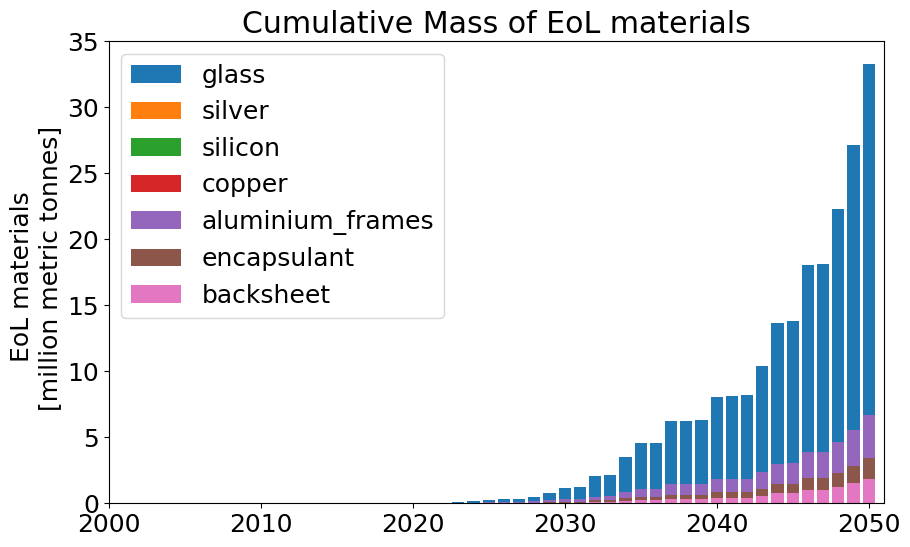

In [91]:
for mat in eol_cumu_all_mats_2050.columns:
    plt.bar(eol_cumu_all_mats_2050.index, eol_cumu_all_mats_2050[mat]/1e6)
plt.legend(MATERIALS)
plt.ylabel('EoL materials \n [million metric tonnes]')
plt.title('Cumulative Mass of EoL materials')
plt.ylim(0,35)
plt.xlim(2000,2051)

## in number of modules and GWs

In [93]:
sim1.scenario['base'].dataOut_m.keys()

Index(['Area', 'Cumulative_Active_Area', 'EOL_BadStatus', 'EOL_Landfill0',
       'EOL_PATHS', 'EOL_PG', 'Effective_Capacity_[W]', 'Landfill_0_ProjLife',
       'MerchantTail_Area', 'MerchantTail_[W]', 'ModuleTotal_MFG', 'P2_stored',
       'P3_reMFG', 'P4_recycled', 'PB1_landfill', 'PB2_stored', 'PB3_reMFG',
       'PB3_reMFG_unyield', 'PB3_reMFG_yield', 'PB4_recycled', 'PG1_landfill',
       'PG2_stored', 'PG3_reMFG', 'PG3_reMFG_unyield', 'PG3_reMFG_yield',
       'PG4_recycled', 'Power_Degraded_[W]', 'Repaired_Area', 'Repaired_[W]',
       'Resold_Area', 'Resold_[W]', 'WeibullParams',
       'Yearly_Sum_Area_EOLby_Degradation', 'Yearly_Sum_Area_EOLby_Failure',
       'Yearly_Sum_Area_EOLby_ProjectLifetime', 'Yearly_Sum_Area_PathsBad',
       'Yearly_Sum_Area_PathsGood', 'Yearly_Sum_Area_atEOL',
       'Yearly_Sum_Power_EOLby_Degradation', 'Yearly_Sum_Power_EOLby_Failure',
       'Yearly_Sum_Power_EOLby_ProjectLifetime', 'Yearly_Sum_Power_PathsBad',
       'Yearly_Sum_Power_PathsGood

In [99]:
modulearea_eol_millionm2 = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/1e6

Text(0, 0.5, 'million meters^2')

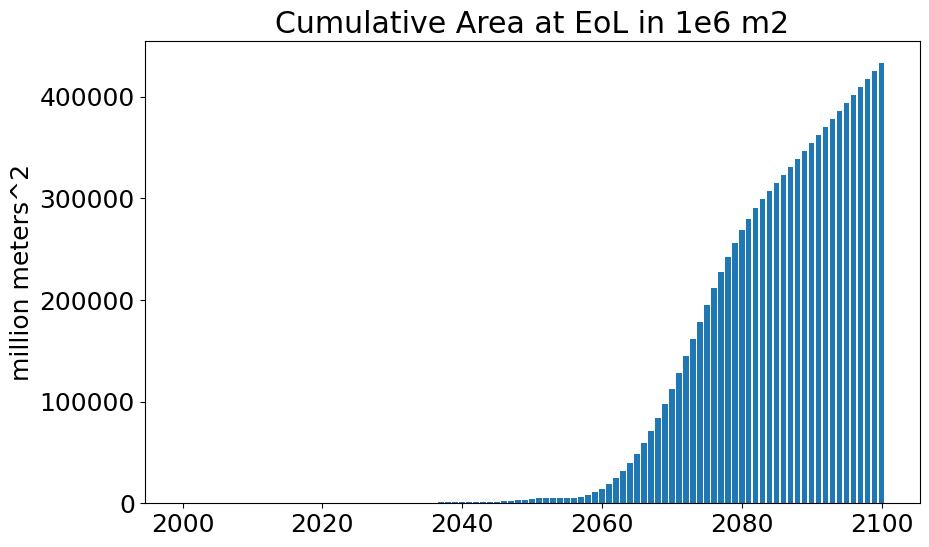

In [108]:
plt.bar(sim1.scenario['base'].dataIn_m['year'], modulearea_eol_millionm2)
plt.ylim(0,)
plt.title('Cumulative Area at EoL in 1e6 m2')
plt.ylabel('million meters^2')

In [139]:
eol_modules_smaller = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/1.6
eol_modules_larger = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/2.75
df_modules = pd.concat([eol_modules_smaller, eol_modules_larger], axis=1)
#, columns=
df_modules.columns = ['Cumulative Modules 1.6m2','Cumulative Modules 2.75m2']
df_modules.index = sim1.scenario['base'].dataIn_m['year']
df_modules

,Cumulative Modules 1.6m2,Cumulative Modules 2.75m2
year,,
2000,0.000000e+00,0.000000e+00
2001,0.000000e+00,0.000000e+00
2002,0.000000e+00,0.000000e+00
2003,0.000000e+00,0.000000e+00
2004,8.923144e-09,5.191647e-09
...,...,...
2096,2.508923e+11,1.459737e+11
2097,2.557952e+11,1.488263e+11
2098,2.606981e+11,1.516789e+11


In [173]:
cumu_power_eol = pd.Series(sim1.scenario['base'].dataOut_m['Yearly_Sum_Power_atEOL'].cumsum()/1e9)#GW
cumu_power_eol.index = sim1.scenario['base'].dataIn_m['year']
df_modules['Cumulative Power at EoL [GW]'] = cumu_power_eol

In [176]:
df_modules
df_modules.to_csv(os.path.join(testfolder, 'output_modules_power_cumuEoL.csv'))